# MAUP Memo Graphs

Population-binned mean plots comparing **block groups** (solid line) and **tracts** (dotted line) for three sets of graph-structural metrics:

1. **Density** — planar graph density (edges / (3n − 6))
2. **Edges and Nodes** — number of edges and number of nodes
3. **Num Leaves and Max Degree** — number of leaf nodes (degree 1) and maximum node degree

Population bins are based on 2020 CBSA total population. Individual CBSA lines are omitted — only bin means are shown.

In [50]:
import json
import glob
import os
import re as _re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D
from matplotlib.gridspec import GridSpec
import pandas as pd

CBSA_DIR = '../study_areas'
VINTAGE  = 'march_2020'

BINS = [
    ('50k–200k',   50_000,   200_000),
    ('200k–500k', 200_000,   500_000),
    ('500k–1M',   500_000, 1_000_000),
    ('1M+',     1_000_000, float('inf')),
]

COLOR_BG     = 'steelblue'
COLOR_TRACTS = 'coral'
LS_BG        = '-'
LS_TRACTS    = '-'

In [51]:
_cbsa_df  = pd.read_csv('cbsa-name dictionary.csv')
cbsa_dict = dict(zip(_cbsa_df['CBSA Code'], _cbsa_df['CBSA Name']))

In [52]:
def load_year(year, census_geography_type, vintage=None, cbsa_names=None):
    pattern = os.path.join(
        CBSA_DIR, str(year),
        f'{census_geography_type}_in_cbsa_*_{year}_*_vintage_connected.json'
    )
    files = sorted(glob.glob(pattern))
    if vintage is not None:
        files = [f for f in files if vintage in os.path.basename(f)]

    records = []
    for fp in files:
        try:
            with open(fp) as f:
                d = json.load(f)
            nodes    = d['nodes']
            adj      = d['adjacency']
            n_nodes  = len(nodes)
            n_edges  = sum(len(a) for a in adj) // 2
            degrees  = [len(a) for a in adj]
            n_leaves = sum(1 for deg in degrees if deg == 1)
            max_deg  = max(degrees) if degrees else 0
            density  = (n_edges / (3 * n_nodes - 6) if n_nodes >= 3 else 0.0)
            sum_totpop = sum((n.get('TOTPOP') or 0) for n in nodes)
            fname = os.path.basename(fp)
            m     = _re.search(r'_in_cbsa_(\d+)_', fname)
            code  = int(m.group(1)) if m else None
            name  = cbsa_names.get(code, '') if cbsa_names and code is not None else ''
            records.append({
                'cbsa_code': code,
                'cbsa_name': name,
                'n_nodes':   n_nodes,
                'n_edges':   n_edges,
                'n_leaves':  n_leaves,
                'max_deg':   max_deg,
                'density':   density,
                'total_pop': sum_totpop,
            })
        except Exception as e:
            print(f'  skipped {os.path.basename(fp)}: {e}')
    return records

In [53]:
data_bg = {}
for yr in [1990, 2000, 2010, 2020]:
    print(f'Loading block groups {yr}...', end=' ', flush=True)
    recs = load_year(yr, 'block_groups', vintage=VINTAGE, cbsa_names=cbsa_dict)
    if recs:
        data_bg[yr] = recs
        print(f'{len(recs)} graphs')
    else:
        print('no files found')

YEARS_BG = sorted(data_bg.keys())
print(f'Block group years: {YEARS_BG}')

Loading block groups 1990... 384 graphs
Loading block groups 2000... 392 graphs
Loading block groups 2010... 392 graphs
Loading block groups 2020... 392 graphs
Block group years: [1990, 2000, 2010, 2020]


In [54]:
data_tr = {}
for yr in [1980, 1990, 2000, 2010, 2020]:
    print(f'Loading tracts {yr}...', end=' ', flush=True)
    recs = load_year(yr, 'tracts', vintage=VINTAGE, cbsa_names=cbsa_dict)
    if recs:
        data_tr[yr] = recs
        print(f'{len(recs)} graphs')
    else:
        print('no files found')

YEARS_TR = sorted(data_tr.keys())
print(f'Tract years: {YEARS_TR}')

Loading tracts 1980... 335 graphs
Loading tracts 1990... 384 graphs
Loading tracts 2000... 392 graphs
Loading tracts 2010... 392 graphs
Loading tracts 2020... 392 graphs
Tract years: [1980, 1990, 2000, 2010, 2020]


In [55]:
cbsa_data_bg = {}
for yr in YEARS_BG:
    for r in data_bg[yr]:
        code = r.get('cbsa_code')
        if code is not None:
            cbsa_data_bg.setdefault(code, {})[yr] = r

cbsa_data_tr = {}
for yr in YEARS_TR:
    for r in data_tr[yr]:
        code = r.get('cbsa_code')
        if code is not None:
            cbsa_data_tr.setdefault(code, {})[yr] = r

# Build 2020 population for bin assignment (BG preferred, tracts fallback)
pop_2020_tr = {
    r['cbsa_code']: r['total_pop']
    for r in data_tr.get(2020, [])
    if r.get('cbsa_code') is not None
}
pop_2020_bg = {
    r['cbsa_code']: r['total_pop']
    for r in data_bg.get(2020, [])
    if r.get('cbsa_code') is not None
}
pop_2020 = {**pop_2020_tr, **pop_2020_bg}  # BG overwrites tracts

bin_codes = [
    [c for c, p in pop_2020.items() if lo <= p < hi]
    for (_, lo, hi) in BINS
]

for (label, lo, hi), codes in zip(BINS, bin_codes):
    print(f'  {label}: {len(codes)} CBSAs')

  50k–200k: 166 CBSAs
  200k–500k: 115 CBSAs
  500k–1M: 54 CBSAs
  1M+: 57 CBSAs


In [56]:
def _bin_mean(cbsa_data, years, codes, metric_key):
    """Return (years_list, means_list) for a metric within a population bin."""
    yrs_out, means_out = [], []
    for yr in years:
        vals = [
            cbsa_data[c][yr][metric_key]
            for c in codes
            if yr in cbsa_data.get(c, {})
            and cbsa_data[c][yr].get(metric_key) is not None
            and not (isinstance(cbsa_data[c][yr].get(metric_key), float)
                     and np.isnan(cbsa_data[c][yr].get(metric_key)))
        ]
        if vals:
            yrs_out.append(yr)
            means_out.append(float(np.mean(vals)))
    return yrs_out, means_out


def binned_plot(metrics, filename, title):
    """
    metrics : list of (metric_key, metric_label) or (metric_key, metric_label, formatter)
    Shows bin-mean lines for block groups (solid steelblue) and tracts (dotted coral).
    """
    metrics = [(m[0], m[1], m[2] if len(m) > 2 else None) for m in metrics]
    n_rows = len(BINS)
    n_cols = len(metrics)
    height_ratios = [h for _ in BINS for h in (0.12, 1.0)]

    fig = plt.figure(figsize=(max(5, 4.5 * n_cols), 3.8 * n_rows))
    fig.suptitle(title, fontsize=15, fontweight='bold', y=0.997)
    gs = GridSpec(2 * n_rows, n_cols, figure=fig,
                  height_ratios=height_ratios, hspace=0.55, wspace=0.35)

    for row, ((bin_label, _, __), codes) in enumerate(zip(BINS, bin_codes)):
        hax = fig.add_subplot(gs[row * 2, :])
        hax.set_axis_off()
        hax.text(0.5, 0.5, f'Bin: {bin_label}  (n={len(codes)})',
                 transform=hax.transAxes, ha='center', va='center',
                 fontsize=12, fontweight='bold')

    axes_grid = [
        [fig.add_subplot(gs[row * 2 + 1, col]) for col in range(n_cols)]
        for row in range(n_rows)
    ]

    all_plot_years = sorted(set(YEARS_BG + YEARS_TR))

    for row, (bin_label, lo, hi) in enumerate(BINS):
        codes = bin_codes[row]
        for col, (metric_key, metric_label, fmt) in enumerate(metrics):
            ax = axes_grid[row][col]

            bg_yrs, bg_vals = _bin_mean(cbsa_data_bg, YEARS_BG, codes, metric_key)
            if bg_yrs:
                ax.plot(bg_yrs, bg_vals, color=COLOR_BG, linewidth=2.2,
                        marker='o', markersize=5, linestyle=LS_BG,
                        zorder=2, label='Block Groups')

            tr_yrs, tr_vals = _bin_mean(cbsa_data_tr, YEARS_TR, codes, metric_key)
            if tr_yrs:
                ax.plot(tr_yrs, tr_vals, color=COLOR_TRACTS, linewidth=2.2,
                        marker='o', markersize=5, linestyle=LS_TRACTS,
                        zorder=2, label='Tracts')

            ax.set_title(metric_label, fontsize=9, fontweight='bold')
            if fmt:
                ax.yaxis.set_major_formatter(fmt)
            ax.set_xticks(all_plot_years)
            ax.tick_params(labelsize=8, axis='x', rotation=30)
            ax.tick_params(labelsize=8, axis='y')
            ax.grid(True, alpha=0.3)

    legend_handles = [
        Line2D([0], [0], color=COLOR_BG,     linewidth=2.2, marker='o', markersize=5,
               linestyle=LS_BG,     label='Block Groups'),
        Line2D([0], [0], color=COLOR_TRACTS, linewidth=2.2, marker='o', markersize=5,
               linestyle=LS_TRACTS, label='Tracts'),
    ]
    fig.legend(handles=legend_handles, loc='lower center', ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.005), framealpha=0.85)

    plt.tight_layout(rect=[0, 0.02, 1, 0.987], pad=0.1)
    os.makedirs('figures', exist_ok=True)
    fig.savefig(f'figures/{filename}', dpi=150, bbox_inches='tight')
    print(f'Saved figures/{filename}')
    plt.show()

Saved figures/maup_memo_density.png


/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_29138/3755621450.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.987], pad=0.1)


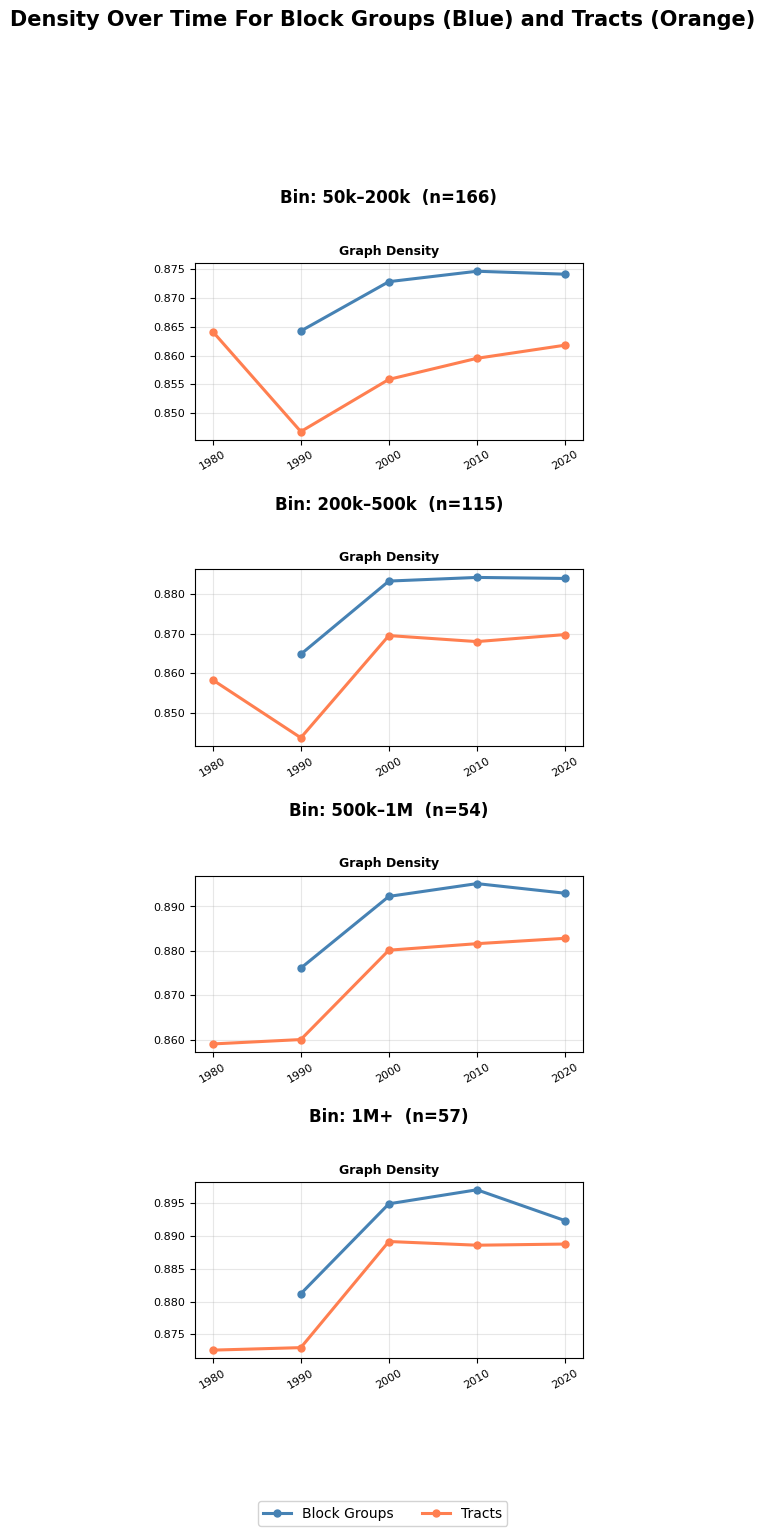

In [68]:
binned_plot(
    [('density', 'Graph Density',
      mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))],
    'maup_memo_density.png',
    'Density Over Time For Block Groups (Blue) and Tracts (Orange)',
)

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_29138/3755621450.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.987], pad=0.1)


Saved figures/maup_memo_edges_nodes.png


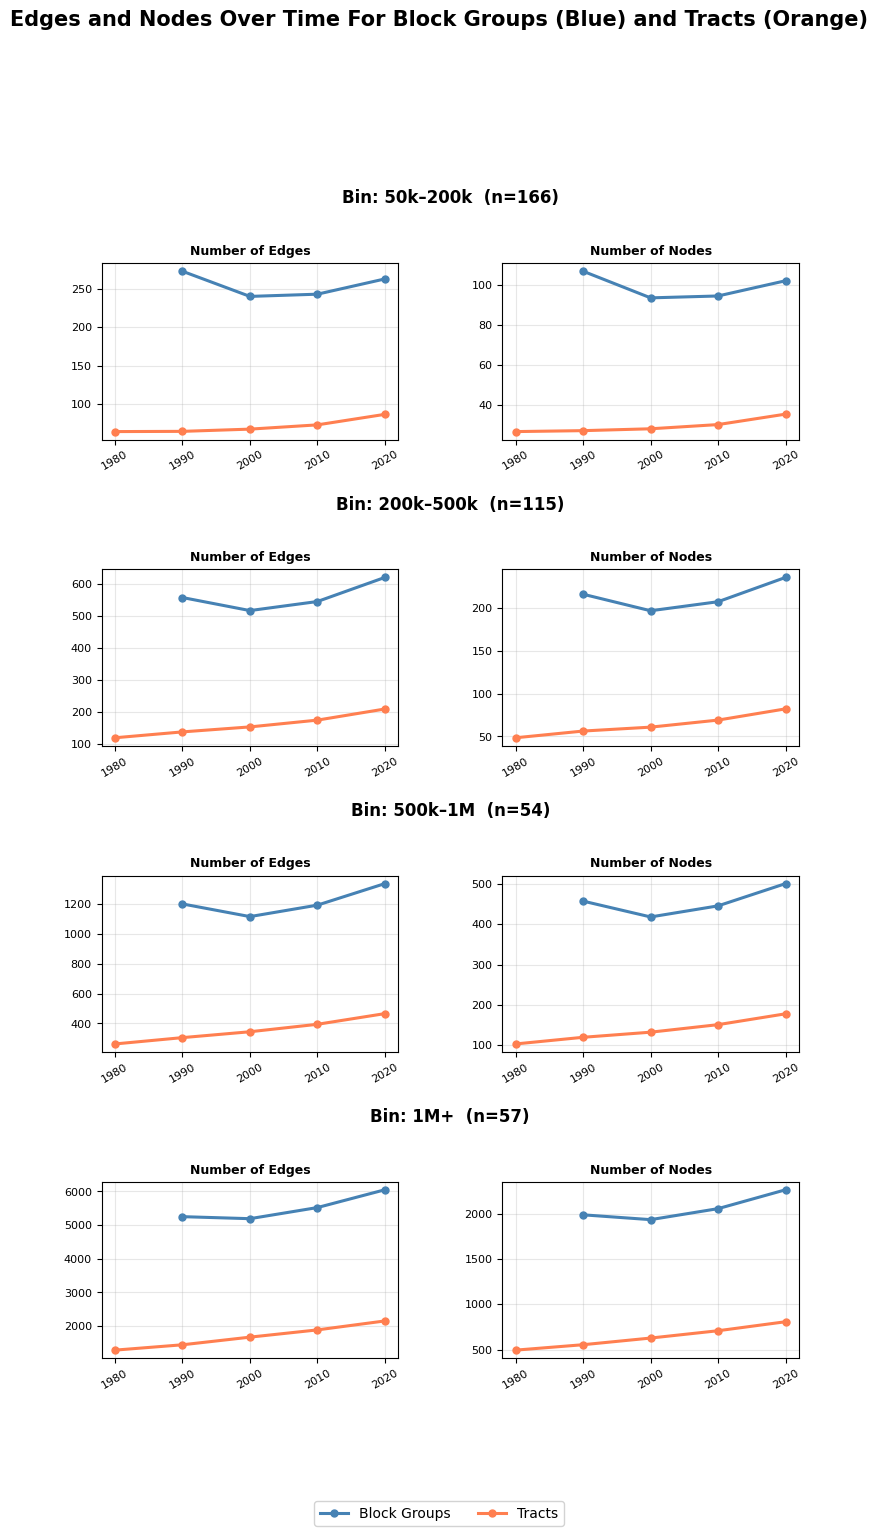

In [66]:
binned_plot(
    [
        ('n_edges', 'Number of Edges'),
        ('n_nodes', 'Number of Nodes'),
    ],
    'maup_memo_edges_nodes.png',
    'Edges and Nodes Over Time For Block Groups (Blue) and Tracts (Orange)',
)

/var/folders/t8/lj11mg1j3x76rrnc0m3pjp5h0000gn/T/ipykernel_29138/3755621450.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.02, 1, 0.987], pad=0.1)


Saved figures/maup_memo_leaves_degree.png


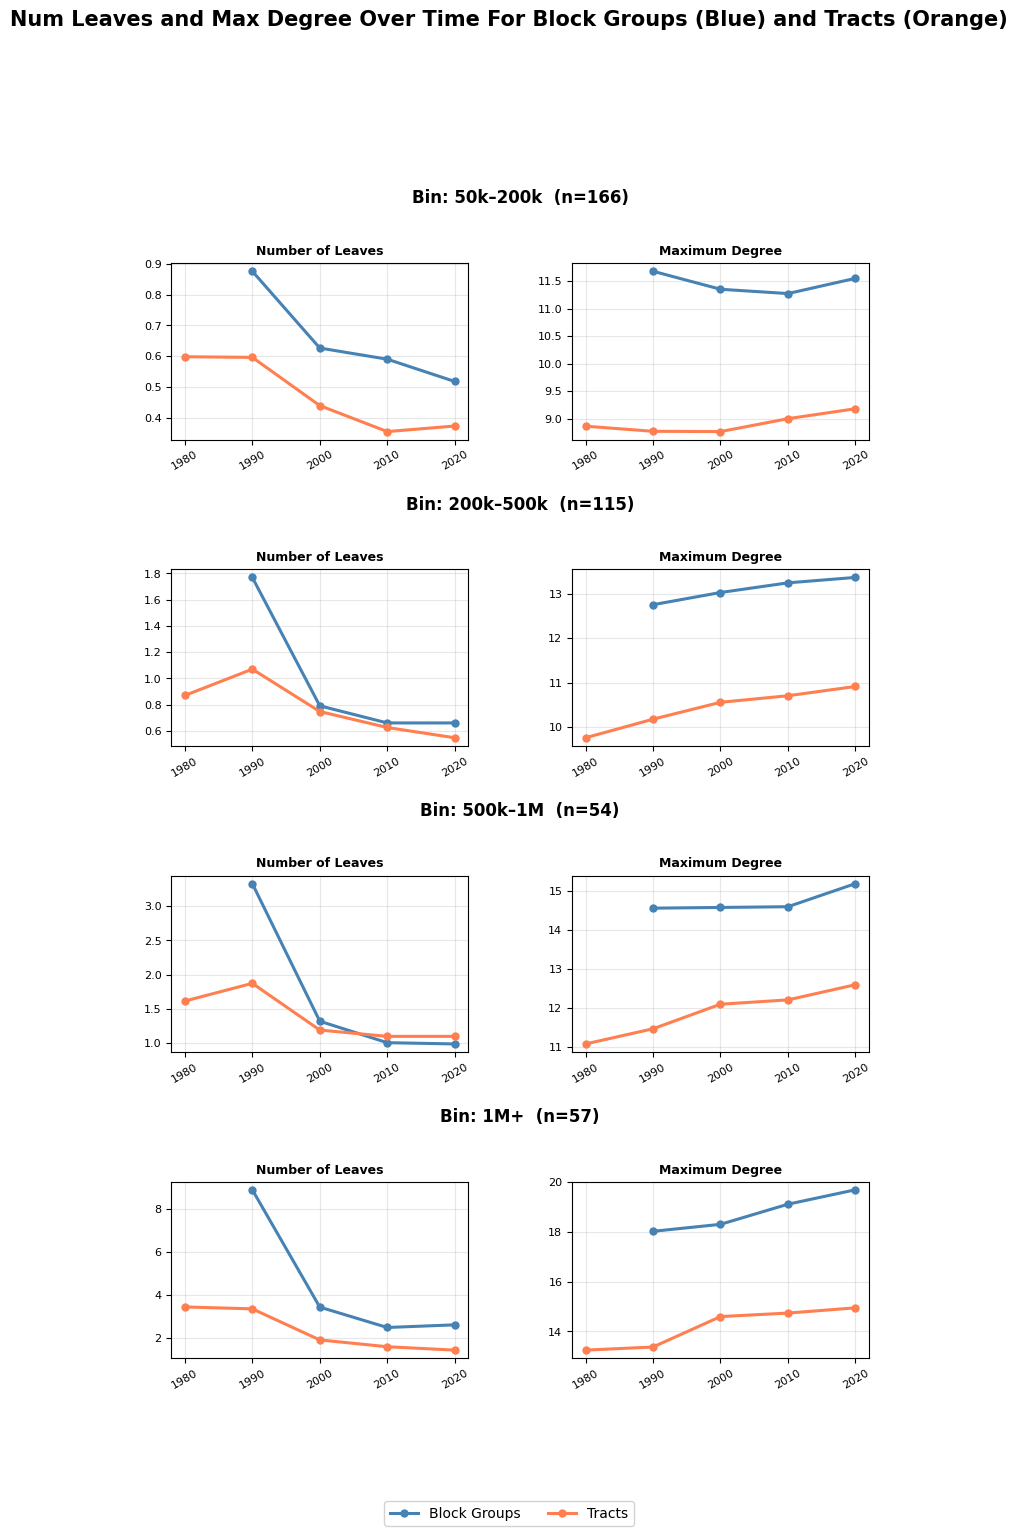

In [67]:
binned_plot(
    [
        ('n_leaves', 'Number of Leaves'),
        ('max_deg',  'Maximum Degree'),
    ],
    'maup_memo_leaves_degree.png',
    'Num Leaves and Max Degree Over Time For Block Groups (Blue) and Tracts (Orange)',
)

## City Spaghetti Plots

Six selected metros — solid lines = tracts, dotted lines = block groups. Each city uses the same color across both geography types.

In [60]:
CITY_CONFIGS = [
    (12060, 'Atlanta',       '#e41a1c'),
    (16980, 'Chicago',       '#377eb8'),
    (19100, 'Dallas',        '#4daf4a'),
    (26420, 'Houston',       '#984ea3'),
    (33100, 'Miami',         '#ff7f00'),
    (37980, 'Philadelphia',  '#a65628'),
]


def city_spaghetti(metric_key, metric_label, fmt=None):
    fig, (ax_tr, ax_bg) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig.suptitle(
        f'{metric_label} Over Time For Block Groups and Tracts',
        fontsize=13, fontweight='bold',
    )

    city_handles = [
        Line2D([0], [0], color=color, linewidth=2.0, marker='o', markersize=5, label=name)
        for _, name, color in CITY_CONFIGS
    ]

    for code, city_name, color in CITY_CONFIGS:
        tr_pts = [
            (yr, cbsa_data_tr[code][yr][metric_key])
            for yr in YEARS_TR
            if yr in cbsa_data_tr.get(code, {})
            and cbsa_data_tr[code][yr].get(metric_key) is not None
            and not (isinstance(cbsa_data_tr[code][yr].get(metric_key), float)
                     and np.isnan(cbsa_data_tr[code][yr].get(metric_key)))
        ]
        if len(tr_pts) >= 2:
            yrs_i, vals_i = zip(*tr_pts)
            ax_tr.plot(yrs_i, vals_i, color=color, linewidth=2.0, linestyle='-',
                       marker='o', markersize=5)

        bg_pts = [
            (yr, cbsa_data_bg[code][yr][metric_key])
            for yr in YEARS_BG
            if yr in cbsa_data_bg.get(code, {})
            and cbsa_data_bg[code][yr].get(metric_key) is not None
            and not (isinstance(cbsa_data_bg[code][yr].get(metric_key), float)
                     and np.isnan(cbsa_data_bg[code][yr].get(metric_key)))
        ]
        if len(bg_pts) >= 2:
            yrs_i, vals_i = zip(*bg_pts)
            ax_bg.plot(yrs_i, vals_i, color=color, linewidth=2.0, linestyle='-',
                       marker='o', markersize=5)

    all_tr_yrs = sorted(set(YEARS_TR))
    all_bg_yrs = sorted(set(YEARS_BG))

    for ax, title, yrs in [
        (ax_tr, 'Tracts',       all_tr_yrs),
        (ax_bg, 'Block Groups', all_bg_yrs),
    ]:
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(yrs)
        ax.tick_params(labelsize=9)
        ax.set_xlabel('Year', fontsize=10)
        ax.grid(True, alpha=0.3)
        if fmt:
            ax.yaxis.set_major_formatter(fmt)

    ax_tr.set_ylabel(metric_label, fontsize=10)
    ax_tr.legend(handles=city_handles, fontsize=8.5, framealpha=0.85)

    plt.tight_layout()
    os.makedirs('figures', exist_ok=True)
    fname = f'maup_spaghetti_{metric_key}.png'
    fig.savefig(f'figures/{fname}', dpi=150, bbox_inches='tight')
    print(f'Saved figures/{fname}')
    plt.show()

Saved figures/maup_spaghetti_n_nodes.png


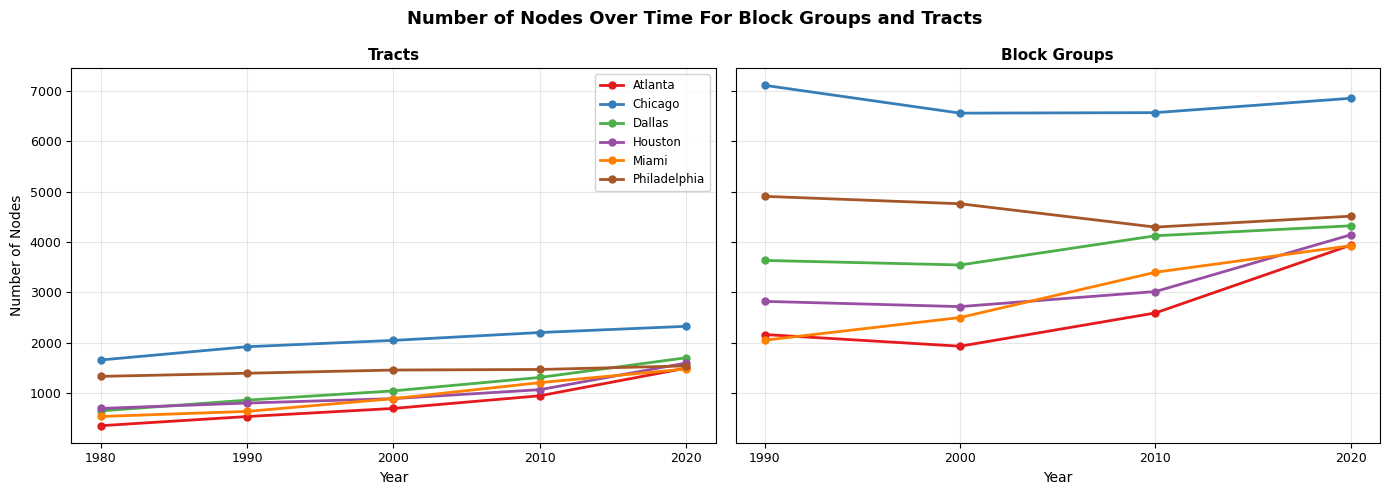

In [61]:
city_spaghetti('n_nodes', 'Number of Nodes')

Saved figures/maup_spaghetti_n_edges.png


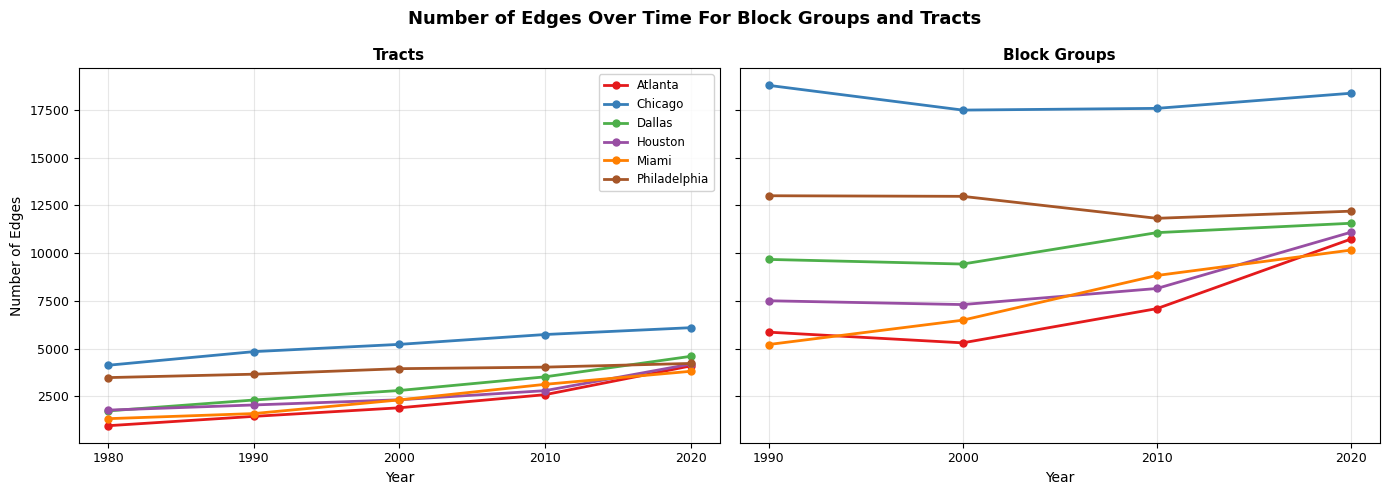

In [62]:
city_spaghetti('n_edges', 'Number of Edges')

Saved figures/maup_spaghetti_density.png


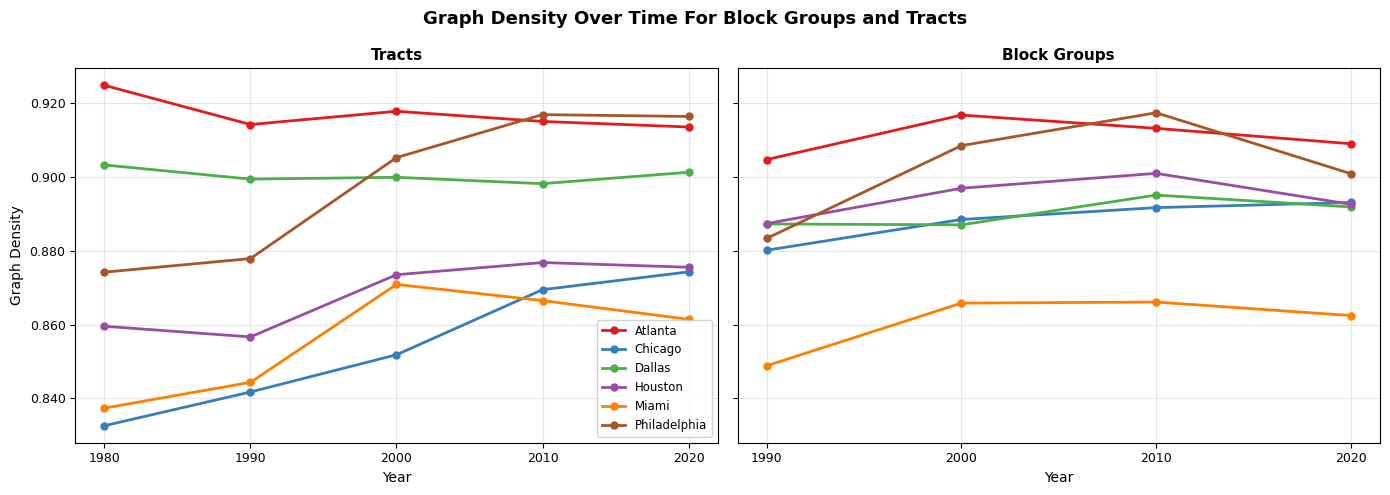

In [63]:
city_spaghetti('density', 'Graph Density',
               fmt=mticker.FuncFormatter(lambda x, _: f'{x:.3f}'))

Saved figures/maup_spaghetti_n_leaves.png


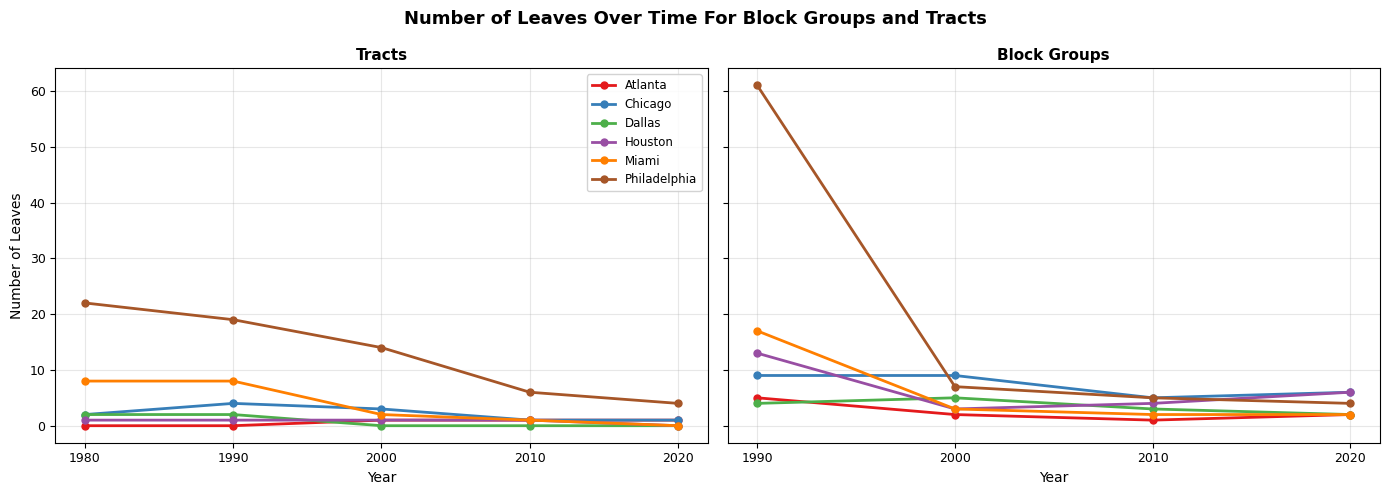

In [64]:
city_spaghetti('n_leaves', 'Number of Leaves')

Saved figures/maup_spaghetti_max_deg.png


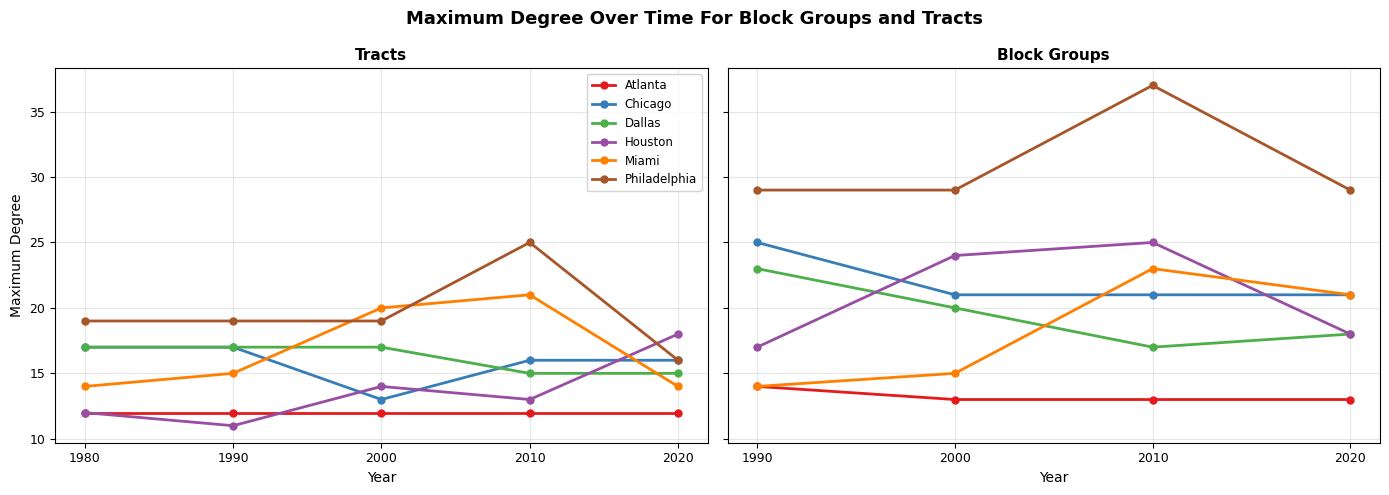

In [65]:
city_spaghetti('max_deg', 'Maximum Degree')